In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df=pd.read_csv("Titanic-Dataset.csv")

In [42]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [43]:
print(df.shape)


(891, 12)


In [44]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


In [45]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [46]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [47]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [48]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [49]:
df = df[["Pclass", "Age", "Fare", "Survived"]]
df.head()

,Pclass,Age,Fare,Survived
0,3,22.0,7.2500,0
1,1,38.0,71.2833,1
2,3,26.0,7.9250,1
3,1,35.0,53.1000,1
4,3,35.0,8.0500,0


In [50]:
print(df.isnull().sum())

Pclass        0
Age         177
Fare          0
Survived      0
dtype: int64


In [51]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
df[["Age"]] = imputer.fit_transform(df[["Age"]])
print(df.isnull().sum())

Pclass      0
Age         0
Fare        0
Survived    0
dtype: int64


In [52]:
X = df[["Pclass", "Age", "Fare"]]
y = df["Survived"]
print(X.shape)
print(y.shape)
print(X.head())
print(y.head())

(891, 3)
(891,)
   Pclass   Age     Fare
0       3  22.0   7.2500
1       1  38.0  71.2833
2       3  26.0   7.9250
3       1  35.0  53.1000
4       3  35.0   8.0500
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(712, 3)
(179, 3)
(712,)
(179,)


In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[ 0.82956755 -0.11207776  0.5138115 ]
 [-0.37094484 -0.11207776 -0.66256323]
 [-1.57145722 -0.11207776  3.95539858]
 [ 0.82956755 -0.87980748 -0.46787435]
 [-0.37094484  0.11824116 -0.11597681]]


In [55]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(X_train_scaled, y_train)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: [-0.52664179]
Coefficients: [[-0.76968631 -0.47160471  0.27777463]]


In [56]:
y_pred = model.predict(X_test_scaled)
print("Actual:")
print(y_test.values[:10])

print()

print("Predicted:")
print(y_pred[:10])

Actual:
[0 0 1 0 1 1 1 0 0 0]

Predicted:
[0 0 0 0 0 0 0 1 1 0]


In [57]:
y_probability = model.predict_proba(X_test_scaled)
print(y_probability[:5])

[[0.73337771 0.26662229]
 [0.85600754 0.14399246]
 [0.73833018 0.26166982]
 [0.84362071 0.15637929]
 [0.76971182 0.23028818]]


In [58]:
probability_table = pd.DataFrame({
    "Probability_Not_Survived": y_probability[:, 0],
    "Probability_Survived": y_probability[:, 1],
    "Predicted": y_pred,
    "Actual": y_test.values
})

probability_table.head(10)

,Probability_Not_Survived,Probability_Survived,Predicted,Actual
0,0.733378,0.266622,0,0
1,0.856008,0.143992,0,0
2,0.738330,0.261670,0,1
3,0.843621,0.156379,0,0
4,0.769712,0.230288,0,1
5,0.815379,0.184621,0,1
6,0.642626,0.357374,0,1
7,0.477577,0.522423,1,0
8,0.393481,0.606519,1,0
9,0.608062,0.391938,0,0


In [59]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6759776536312849

Confusion Matrix:
[[94 16]
 [42 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.85      0.76       110
           1       0.63      0.39      0.48        69

    accuracy                           0.68       179
   macro avg       0.66      0.62      0.62       179
weighted avg       0.67      0.68      0.66       179



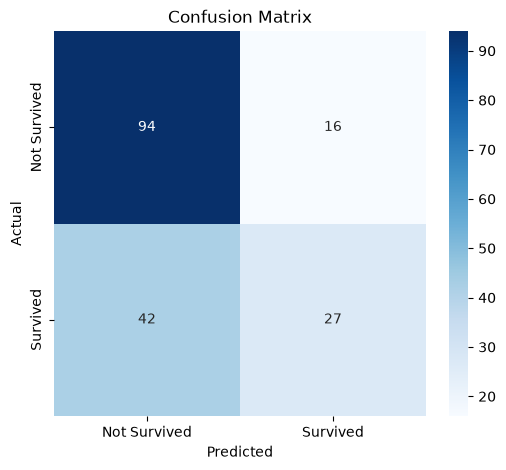

In [60]:

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [61]:
from sklearn.svm import SVC

svc_model = SVC(kernel='linear',random_state=42)
svc_model.fit(X_train_scaled,y_train)



,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [62]:
y_pred_svc=svc_model.predict(X_test_scaled)

In [63]:
svc_accuracy = accuracy_score(y_test, y_pred_svc)

print(f"SVC Accuracy: {svc_accuracy:.3f}")

print(classification_report(y_test, y_pred_svc))

SVC Accuracy: 0.682
              precision    recall  f1-score   support

           0       0.72      0.79      0.75       110
           1       0.60      0.51      0.55        69

    accuracy                           0.68       179
   macro avg       0.66      0.65      0.65       179
weighted avg       0.67      0.68      0.68       179



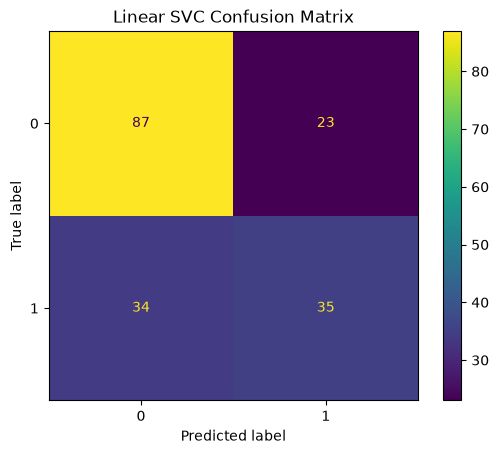

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc)

plt.title("Linear SVC Confusion Matrix")
plt.show()

In [66]:
svc_rbf = SVC(
    kernel="rbf",
    gamma="scale",
    random_state=42
)

svc_rbf.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [71]:
y_pred_rbf = svc_rbf.predict(X_test_scaled)

In [68]:
from sklearn.metrics import accuracy_score

rbf_accuracy = accuracy_score(y_test, y_pred_rbf)

print(f"RBF SVC Accuracy: {rbf_accuracy:.3f}")

RBF SVC Accuracy: 0.682


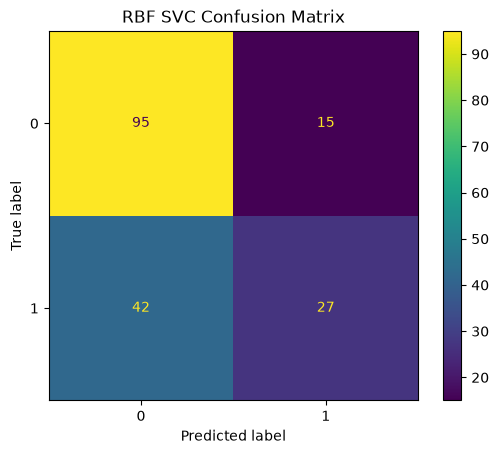

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rbf)

plt.title("RBF SVC Confusion Matrix")
plt.show()

In [70]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVC",
        "RBF SVC"
    ],
    "Accuracy": [
        accuracy,
        svc_accuracy,
        rbf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.675978
1,Linear SVC,0.681564
2,RBF SVC,0.681564


In [72]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("Best Model")
print(best_model)

Best Model
Model       Linear SVC
Accuracy      0.681564
Name: 1, dtype: object


(0.0, 1.0)

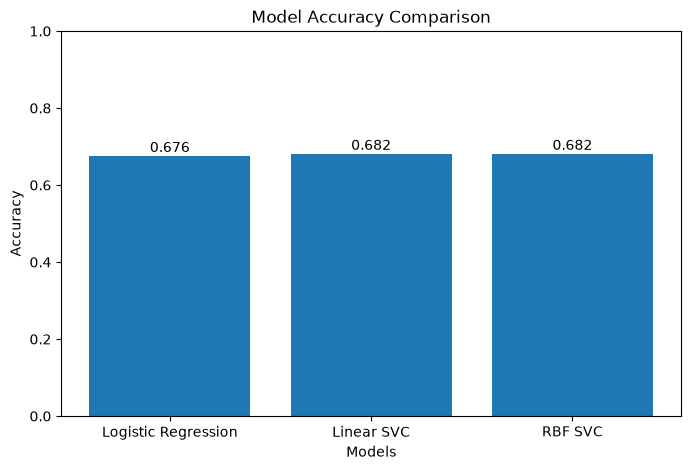

In [74]:
models = ["Logistic Regression", "Linear SVC", "RBF SVC"]
accuracies = [accuracy, svc_accuracy, rbf_accuracy]

plt.figure(figsize=(8, 5))

bars=plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center"
    )

plt.ylim(0, 1)